--- 准备工作：生成【动态】物理数据与定义网络图纸 ---

--- 实验一：Latent Dimension 消融实验 ---
开始训练 latent_dim = 1 的自动编码器...
开始训练 latent_dim = 32 的自动编码器...


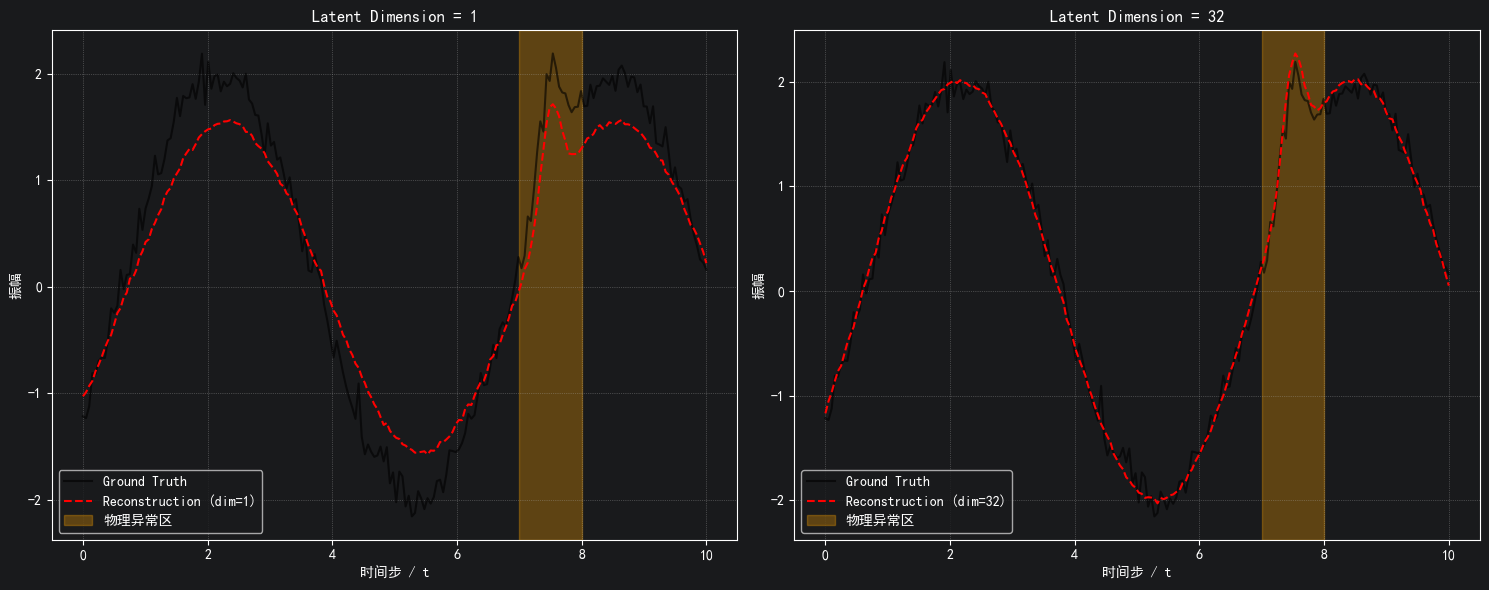

In [3]:
import torch
import torch.nn as nn
import torch.optim as optim
import numpy as np
import matplotlib.pyplot as plt

plt.rcParams['font.sans-serif'] = ['SimHei']
plt.rcParams['axes.unicode_minus'] = False
torch.manual_seed(42)
np.random.seed(42)

print("--- 准备工作：生成【动态】物理数据与定义网络图纸 ---")

time_steps = 200
t = np.linspace(0, 10, time_steps)

def generate_physical_signals(num_samples):
    signals = []
    for _ in range(num_samples):
        phase = np.random.uniform(0, 2*np.pi)
        macro_background = 2.0 * np.sin(t + phase)

        anomaly_amp = np.random.uniform(0.5, 1.5)
        critical_anomaly = anomaly_amp * np.exp(-((t - 7.5)**2) / 0.05)

        noise = np.random.normal(0, 0.1, time_steps)
        signal = macro_background + critical_anomaly + noise
        signals.append(signal)
    return torch.tensor(np.array(signals), dtype=torch.float32)

X_train = generate_physical_signals(1000)
X_test = generate_physical_signals(1)

class ScientificAutoencoder(nn.Module):
    def __init__(self, input_dim=200, latent_dim=4):
        super().__init__()
        self.encoder = nn.Sequential(
            nn.Linear(input_dim, 128),
            nn.ReLU(),
            nn.Linear(128, latent_dim)
        )
        self.decoder = nn.Sequential(
            nn.Linear(latent_dim, 128),
            nn.ReLU(),
            nn.Linear(128, input_dim)
        )

    def forward(self, x):
        z = self.encoder(x)
        return self.decoder(z)

# =========================================================

print("\n--- 实验一：Latent Dimension 消融实验 ---")

dims_to_test = [1, 32]
plt.figure(figsize=(15, 6))

for i, dim in enumerate(dims_to_test):
    print(f"开始训练 latent_dim = {dim} 的自动编码器...")
    model = ScientificAutoencoder(input_dim=200, latent_dim=dim)

    optimizer = optim.Adam(model.parameters(), lr=0.005)
    criterion = nn.MSELoss()

    for epoch in range(300):
        model.train()
        optimizer.zero_grad()
        X_recon = model(X_train)
        loss = criterion(X_recon, X_train)
        loss.backward()
        optimizer.step()

    model.eval()
    with torch.no_grad():
        test_signal = X_test[0]
        reconstructed_signal = model(X_test)[0]

    plt.subplot(1, 2, i+1)
    plt.plot(t, test_signal.numpy(), label='Ground Truth', color='black', alpha=0.6)
    plt.plot(t, reconstructed_signal.numpy(), label=f'Reconstruction (dim={dim})', color='red', linestyle='--')
    plt.axvspan(7.0, 8.0, color='orange', alpha=0.3, label='物理异常区')
    plt.title(f"Latent Dimension = {dim}")
    plt.xlabel("时间步 / t")
    plt.ylabel("振幅")
    plt.legend(loc='lower left')
    plt.grid(True, linestyle=':', alpha=0.6)

plt.tight_layout()
plt.show()

=== 实验二：硬核突破 MSE 独裁 (加权 Loss 标准答案版) ===

[开始训练] Latent Dimension 锁定为 4, 开启物理区域加权 (Weight=50)...
  Epoch [50/300], 实时加权 Loss: 0.1441
  Epoch [100/300], 实时加权 Loss: 0.1090
  Epoch [150/300], 实时加权 Loss: 0.0785
  Epoch [200/300], 实时加权 Loss: 0.0608
  Epoch [250/300], 实时加权 Loss: 0.0576
  Epoch [300/300], 实时加权 Loss: 0.0585


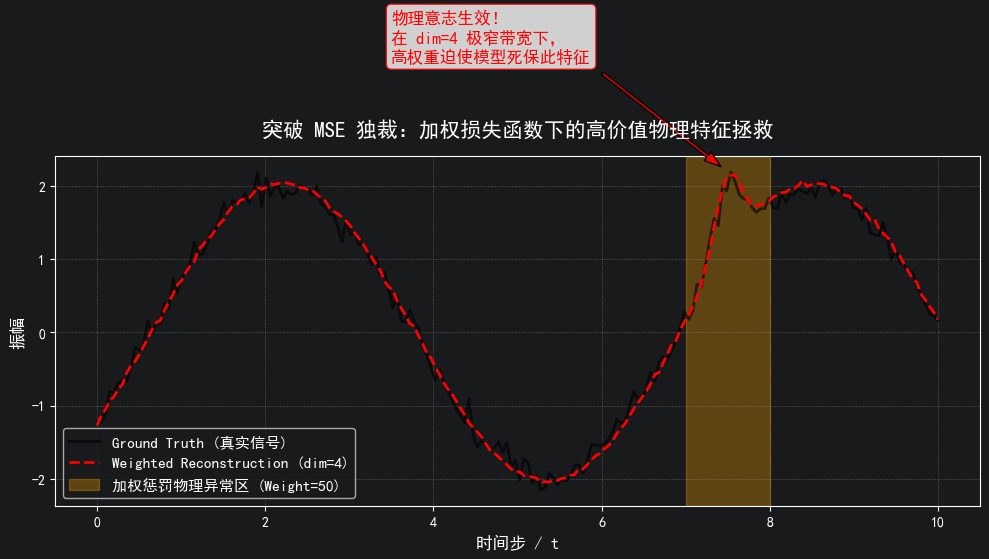

In [8]:
import torch
import torch.nn as nn
import torch.optim as optim
import numpy as np
import matplotlib.pyplot as plt

plt.rcParams['font.sans-serif'] = ['SimHei']
plt.rcParams['axes.unicode_minus'] = False
torch.manual_seed(42)
np.random.seed(42)

print("=== 实验二：硬核突破 MSE 独裁 (加权 Loss 标准答案版) ===")

time_steps = 200
t = np.linspace(0, 10, time_steps)

def generate_physical_signals(num_samples):
    signals = []
    for _ in range(num_samples):
        phase = np.random.uniform(0, 2*np.pi)
        macro_background = 2.0 * np.sin(t + phase)
        anomaly_amp = np.random.uniform(0.5, 1.5)
        critical_anomaly = anomaly_amp * np.exp(-((t - 7.5)**2) / 0.05)
        noise = np.random.normal(0, 0.1, time_steps)
        signals.append(macro_background + critical_anomaly + noise)
    return torch.tensor(np.array(signals), dtype=torch.float32)

X_train = generate_physical_signals(1000)
X_test = generate_physical_signals(1)

class ScientificAutoencoder(nn.Module):
    def __init__(self, input_dim=200, latent_dim=4):
        super().__init__()
        self.encoder = nn.Sequential(
            nn.Linear(input_dim, 128),
            nn.ReLU(),
            nn.Linear(128, latent_dim)
        )
        self.decoder = nn.Sequential(
            nn.Linear(latent_dim, 128),
            nn.ReLU(),
            nn.Linear(128, input_dim)
        )
    def forward(self, x):
        return self.decoder(self.encoder(x))

model_weighted = ScientificAutoencoder(input_dim=200, latent_dim=4)
optimizer_weighted = optim.Adam(model_weighted.parameters(), lr=0.005)
epochs = 300

print(f"\n[开始训练] Latent Dimension 锁定为 4, 开启物理区域加权 (Weight=50)...")

for epoch in range(epochs):
    model_weighted.train()
    optimizer_weighted.zero_grad()

    X_reconstructed = model_weighted(X_train)

    squared_errors = (X_reconstructed - X_train) ** 2

    weight_mask = torch.ones_like(squared_errors)

    weight_mask[:, 140:160] = 50.0

    weighted_squared_errors = squared_errors * weight_mask
    loss = weighted_squared_errors.mean()

    loss.backward()
    optimizer_weighted.step()

    if (epoch + 1) % 50 == 0:
        print(f"  Epoch [{epoch + 1}/{epochs}], 实时加权 Loss: {loss.item():.4f}")

model_weighted.eval()
with torch.no_grad():
    test_signal = X_test[0]
    reconstructed_weighted = model_weighted(X_test)[0]

plt.figure(figsize=(10, 6))
plt.plot(t, test_signal.numpy(), label='Ground Truth (真实信号)', color='black', alpha=0.6, linewidth=2)
plt.plot(t, reconstructed_weighted.numpy(), label='Weighted Reconstruction (dim=4)', color='red', linestyle='--', linewidth=2)
plt.axvspan(7.0, 8.0, color='orange', alpha=0.3, label='加权惩罚物理异常区 (Weight=50)')

anomaly_peak_y = test_signal[150].item()
plt.annotate('物理意志生效！\n在 dim=4 极窄带宽下，\n高权重迫使模型死保此特征',
             xy=(7.5, anomaly_peak_y),
             xytext=(3.5, anomaly_peak_y + 1.5),
             arrowprops=dict(facecolor='red', shrink=0.05, width=2, headwidth=8),
             fontsize=12, fontweight='bold', color='red',
             bbox=dict(boxstyle="round,pad=0.3", edgecolor="red", facecolor="white", alpha=0.8))

plt.title("突破 MSE 独裁：加权损失函数下的高价值物理特征拯救", fontsize=15, pad=15)
plt.xlabel("时间步 / t", fontsize=12)
plt.ylabel("振幅", fontsize=12)
plt.legend(loc='lower left', fontsize=11)
plt.grid(True, linestyle=':', alpha=0.6)
plt.tight_layout()
plt.show()